# ___ Modeling Draft 5 ___ 


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
## Chargement des Données

In [39]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")

X_train : (1600, 20) | X_test : (400, 20)


---
## Sélection des Features (Version Reduced)
* Suppression des features à risque de data leakage (échographie)


In [40]:
leakage_features = ['Follicle No. (L)', 'Follicle No. (R)', 
                    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)']

X_train_red = X_train.drop(columns=leakage_features, errors='ignore')
X_test_red  = X_test.drop(columns=leakage_features, errors='ignore')

print(f"Nombre de features conservées : {X_train_red.shape[1]}")

Nombre de features conservées : 16


---
##  Comparaison de 3 Familles de Modèles

In [41]:
models = {
    "LightGBM (Boosting)": LGBMClassifier(n_estimators=400, learning_rate=0.08, max_depth=6, random_state=42, verbose=-1),
    "Random Forest (Bagging)": RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipeline.fit(X_train_red, y_train)
    
    y_pred = pipeline.predict(X_test_red)
    y_prob = pipeline.predict_proba(X_test_red)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_f1 = cross_val_score(pipeline, X_train_red, y_train, cv=cv, scoring='f1').mean()
    
    results.append({'Modèle': name, 'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4), 'CV_F1': round(cv_f1, 4)})
    print(f"{name:28} = F1: {f1:.4f} | AUC: {auc:.4f} | CV_F1: {cv_f1:.4f}")

c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

LightGBM (Boosting)          = F1: 0.9878 | AUC: 0.9975 | CV_F1: 0.9762
Random Forest (Bagging)      = F1: 0.9587 | AUC: 0.9966 | CV_F1: 0.9328
Logistic Regression          = F1: 0.8170 | AUC: 0.9069 | CV_F1: 0.7668


In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)
results_df

,Modèle,F1-Score,ROC-AUC,CV_F1
0,LightGBM (Boosting),0.9878,0.9975,0.9762
1,Random Forest (Bagging),0.9587,0.9966,0.9328
2,Logistic Regression,0.8170,0.9069,0.7668


___
## Meilleur Modèle : LightGBM

In [43]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LGBMClassifier(
        n_estimators=250,
        learning_rate=0.04,
        max_depth=5,
        num_leaves=20,
        random_state=42,
        verbose=-1,
        min_child_samples=50,
        reg_alpha=2.0,
        reg_lambda=2.0,
        min_split_gain=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])

best_model.fit(X_train_red, y_train)

y_pred = best_model.predict(X_test_red)
y_prob = best_model.predict_proba(X_test_red)[:, 1]

print("\n" + "="*60)
print("Rapport de classification - Modèle Final LightGBM")
print("="*60)
print(classification_report(y_test, y_pred))


Rapport de classification - Modèle Final LightGBM
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       278
           1       0.94      0.96      0.95       122

    accuracy                           0.97       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.97      0.97       400



c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


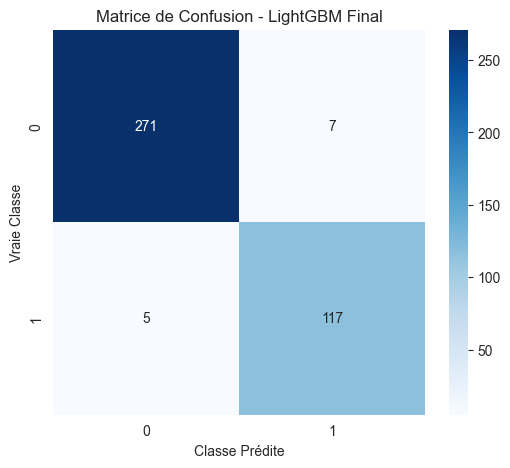

In [44]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - LightGBM Final')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

___
## Feature Importance

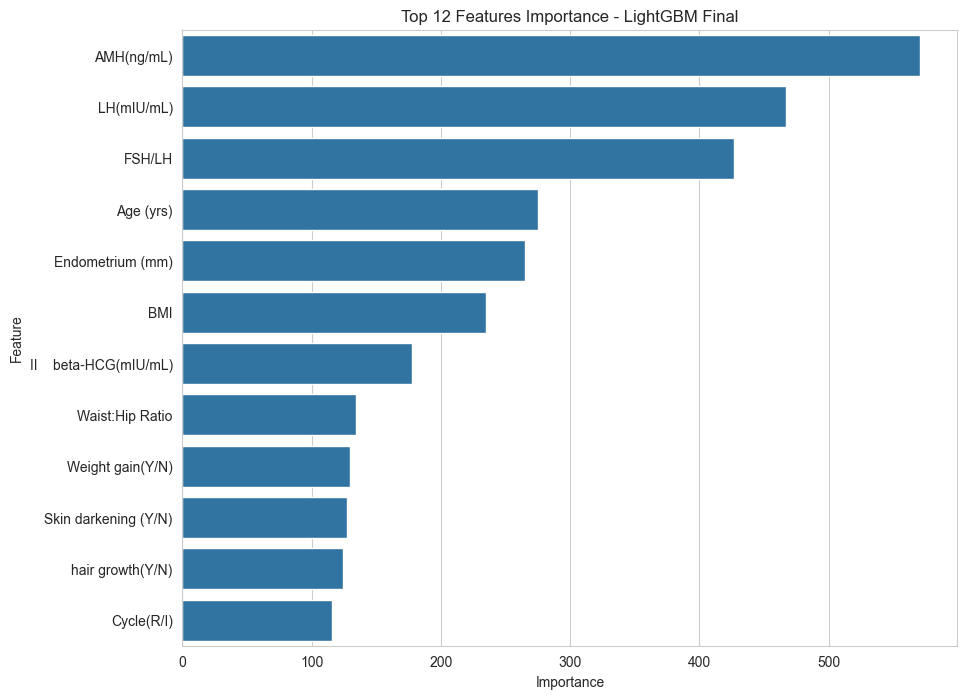

In [45]:
importances = pd.DataFrame({
    'Feature': X_train_red.columns,
    'Importance': best_model.named_steps['clf'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(12), x='Importance', y='Feature')
plt.title('Top 12 Features Importance - LightGBM Final')
plt.show()

## Test 2 cas 

In [46]:
test_non = pd.DataFrame([{
    'Weight gain(Y/N)': 0,
    'hair growth(Y/N)': 0,
    'Skin darkening (Y/N)': 0,
    'Pimples(Y/N)': 0,
    'Hair loss(Y/N)': 0,
    'AMH(ng/mL)': 1.1,
    'Cycle(R/I)': 4,
    'BMI': 19.2,
    'Waist:Hip Ratio': 0.74,
    'LH(mIU/mL)': 2.4,
    'FSH/LH': 2.3,
    'II    beta-HCG(mIU/mL)': 0.8,
    'Age (yrs)': 22,
    'Pregnant(Y/N)': 0,
    'Endometrium (mm)': 5.2,
    'Fast food (Y/N)': 0
}])[X_train_red.columns]

prob_non = best_model.predict_proba(test_non)[0][1] * 100
print(f"Cas 1 - Non-PCOS → Probabilité PCOS : {prob_non:.1f}%")

# Cas 2 : PCOS (avec plusieurs signes forts)
test_oui = pd.DataFrame([{
    'Weight gain(Y/N)': 1,
    'hair growth(Y/N)': 1,
    'Skin darkening (Y/N)': 1,
    'Pimples(Y/N)': 1,
    'Hair loss(Y/N)': 1,
    'AMH(ng/mL)': 8.5,
    'Cycle(R/I)': 2,
    'BMI': 29.5,
    'Waist:Hip Ratio': 0.95,
    'LH(mIU/mL)': 14.5,
    'FSH/LH': 0.55,
    'II    beta-HCG(mIU/mL)': 2.5,
    'Age (yrs)': 31,
    'Pregnant(Y/N)': 0,
    'Endometrium (mm)': 11.8,
    'Fast food (Y/N)': 1
}])[X_train_red.columns]

prob_oui = best_model.predict_proba(test_oui)[0][1] * 100
print(f"Cas 2 - PCOS      → Probabilité PCOS : {prob_oui:.1f}%")

Cas 1 - Non-PCOS → Probabilité PCOS : 59.7%
Cas 2 - PCOS      → Probabilité PCOS : 96.0%


c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Enregistrer le modèle et les features

In [47]:
import joblib
import os
os.makedirs("../model", exist_ok=True)

joblib.dump(best_model, "../model/pcos_model.pkl")
joblib.dump(X_train_red.columns.tolist(), "../model/features.pkl")

print("\nModèle et features sauvegardés avec succès !")


Modèle et features sauvegardés avec succès !
